In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd 
from sklearn.datasets import fetch_california_housing
data=fetch_california_housing()
df=pd.DataFrame(data.data,columns=data.feature_names)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
df['price']=data.target

Convert Target -> Indian Rupees 

In [4]:
# Convert to Indian Rupees
df['Price_Rs'] = df['price'] * 100000 * 83   # USD → INR

# Convert to Lakhs
df['Price_Lakhs'] = df['Price_Rs'] / 100000

# Drop old target
df.drop(['price', 'Price_Rs'], axis=1, inplace=True)

# EDA 

In [5]:
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price_Lakhs  
0    -122.23      375.658  
1    -122.22      297.555  
2    -122.24      292.243  
3    -122.25      283.279  
4    -122.25      284.026  


In [6]:
df.shape

(20640, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   Price_Lakhs  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [8]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price_Lakhs
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,171.690328
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,95.778361
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,12.449170
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,99.268000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,149.151000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,219.721750
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,415.000830


In [9]:
df.skew().sort_values(ascending=False)

AveOccup       97.639561
AveBedrms      31.316956
AveRooms       20.697869
Population      4.935858
MedInc          1.646657
Price_Lakhs     0.977763
Latitude        0.465953
HouseAge        0.060331
Longitude      -0.297801
dtype: float64

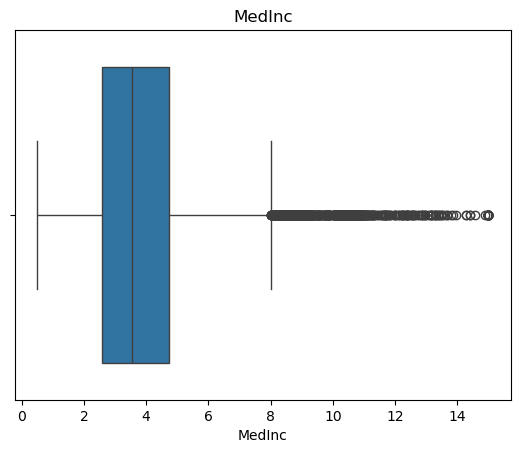

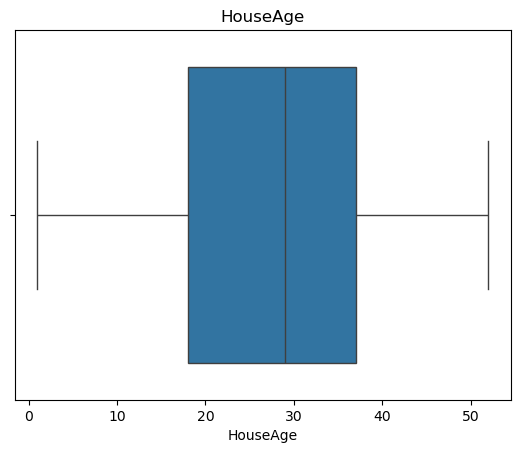

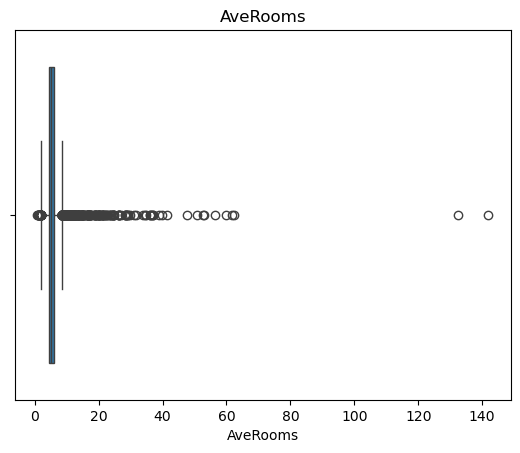

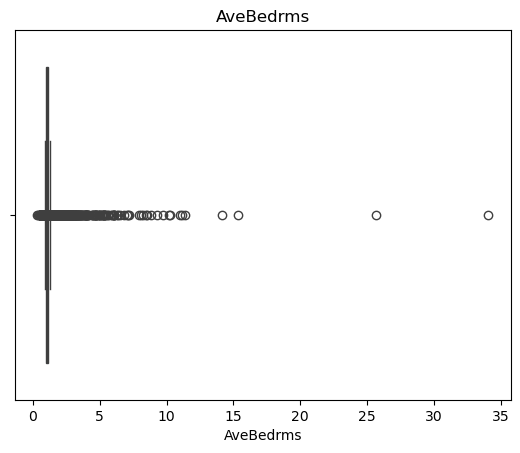

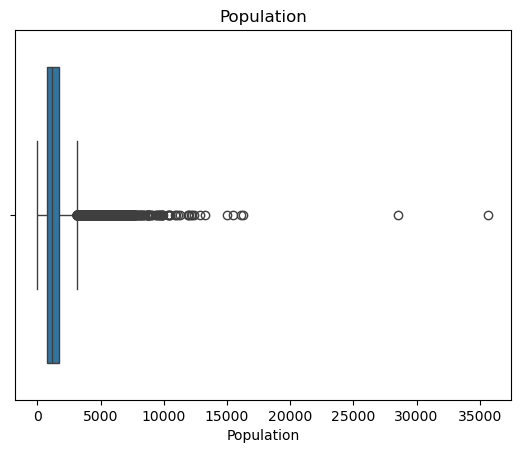

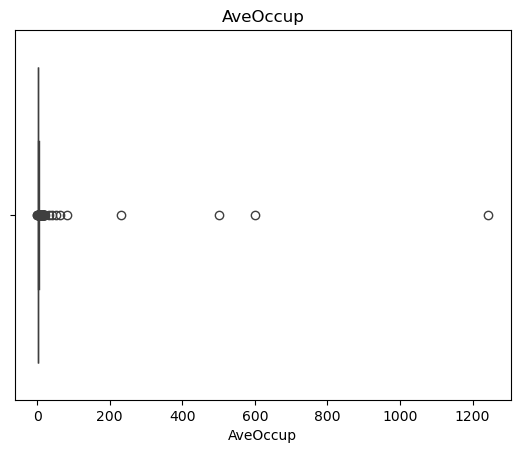

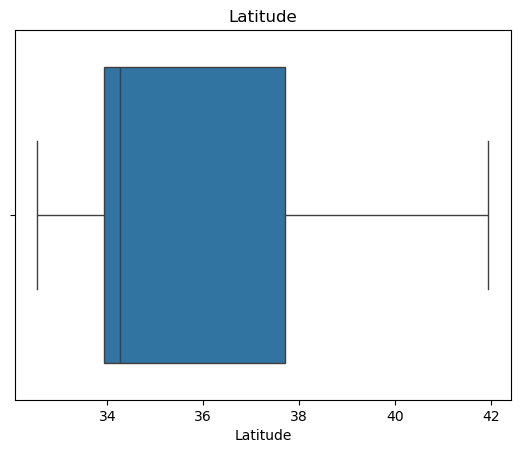

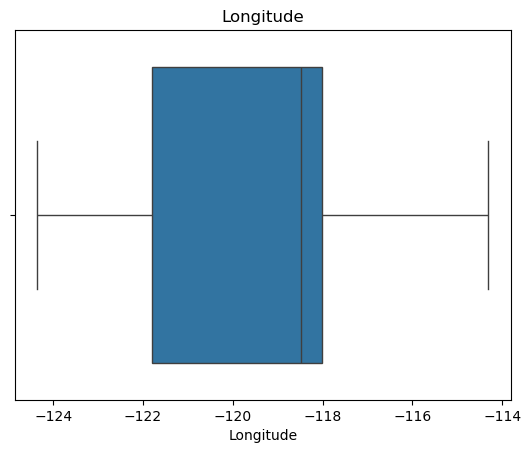

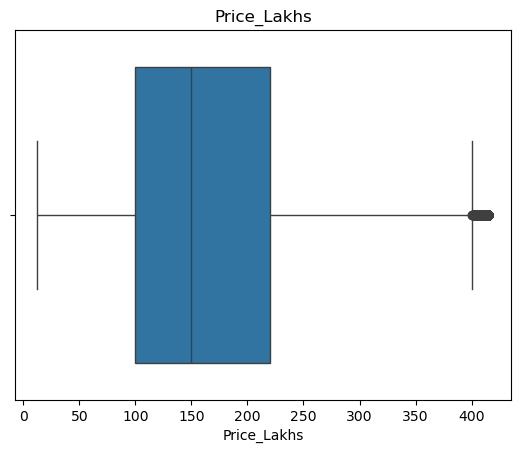

In [10]:
import matplotlib.pyplot as plt 
import seaborn as sns
num_cols=df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [11]:
import numpy as np 
skewed_cols=['AveOccup','AveBedrms','AveRooms','Population','MedInc','Price_Lakhs']
for col in skewed_cols:
    df[col]=np.log1p(df[col])

In [12]:
for col in num_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    df[col]=np.clip(df[col],lower,upper)

In [13]:
df[skewed_cols].skew()

AveOccup       0.176024
AveBedrms      0.418117
AveRooms      -0.035190
Population    -0.168756
MedInc         0.147855
Price_Lakhs   -0.142040
dtype: float64

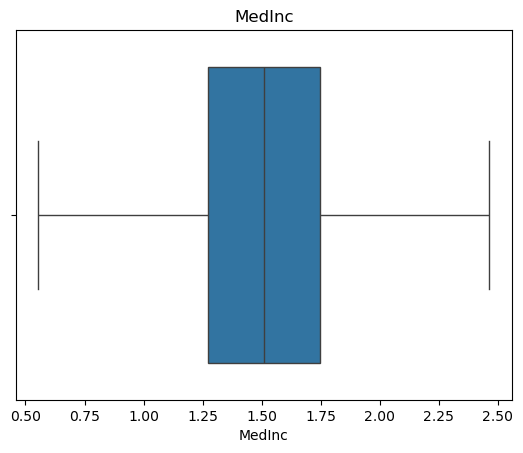

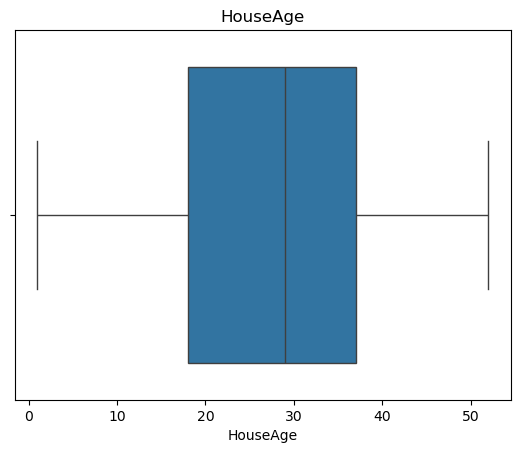

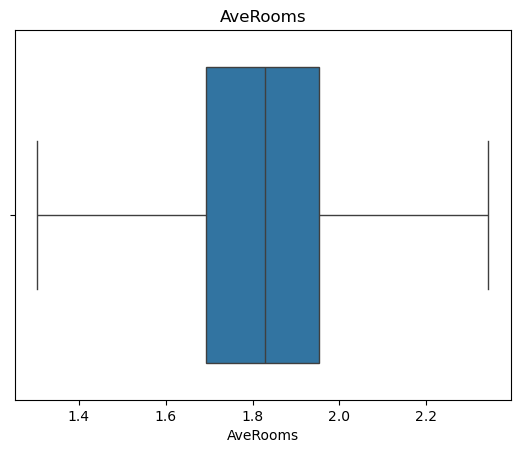

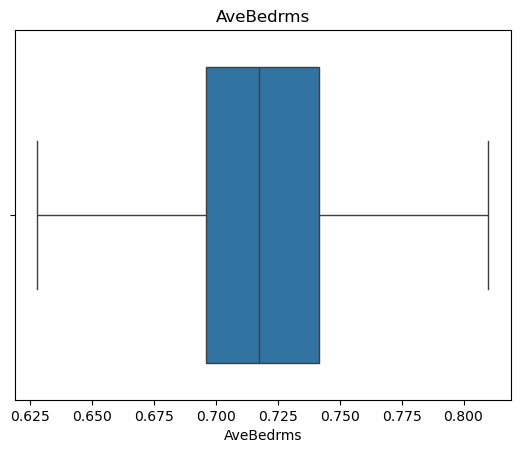

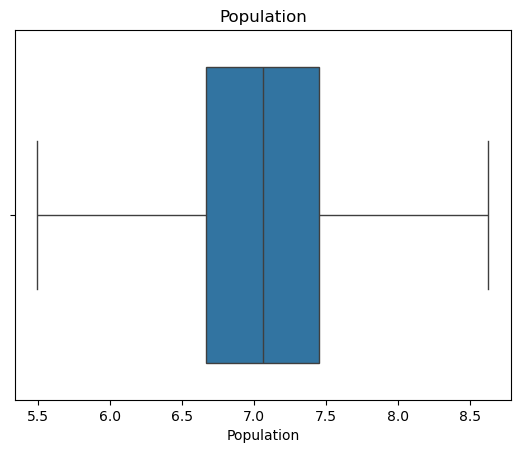

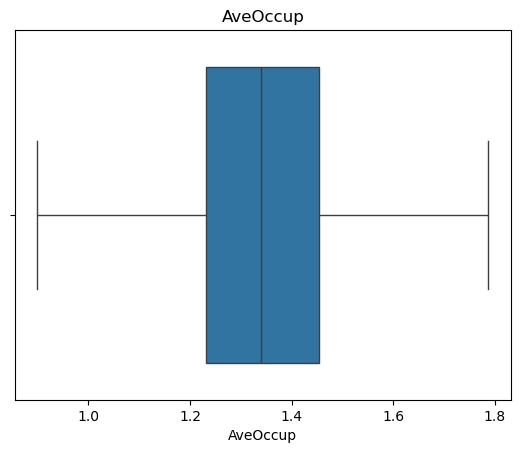

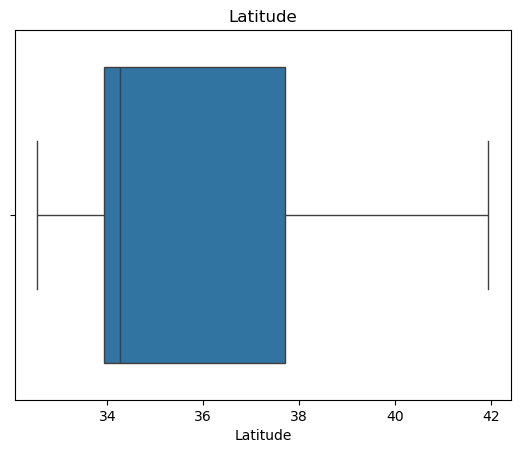

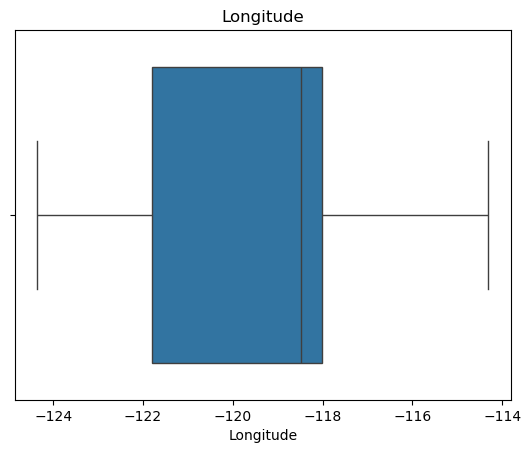

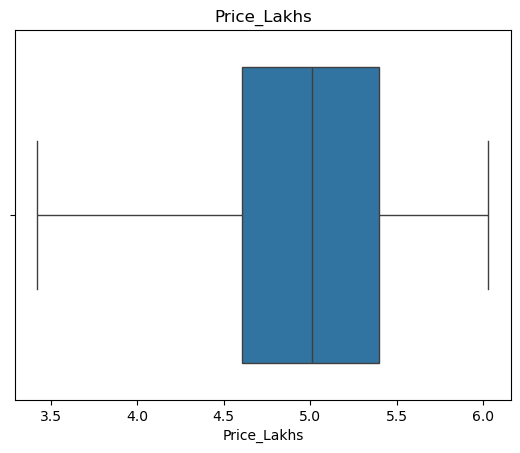

In [14]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

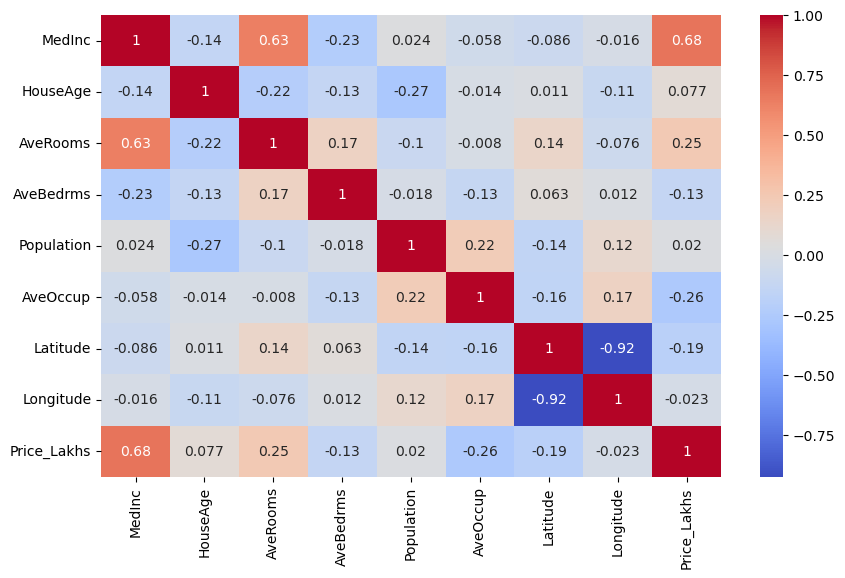

In [15]:
# Check correlation
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Split Features and Target

In [16]:
from sklearn.model_selection import train_test_split
X=df.drop('Price_Lakhs',axis=1)
y=df['Price_Lakhs']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Scaling

In [17]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
models={
    "Linear Regression":LinearRegression(),
    "KNN":KNeighborsRegressor(n_neighbors=5),
    "Decision Tree":DecisionTreeRegressor(max_depth=5,random_state=42),
    "Random Forest":RandomForestRegressor()
}

In [19]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
for name,model in models.items():
    if name in ['Linear Regression','KNN']:
        model.fit(X_train_scaled,y_train)
        pred=model.predict(X_test_scaled)
        train_score=model.score(X_train_scaled,y_train)
        test_score=r2_score(y_test,pred)
    else:
        model.fit(X_train,y_train)
        pred=model.predict(X_test)
        train_score=model.score(X_train,y_train)
        test_score=r2_score(y_test,pred)
    mae=mean_absolute_error(y_test,pred)
    mse=mean_squared_error(y_test,pred)
    rmse=np.sqrt(mse)
    print(name)
    print("Train :",train_score)
    print("Test :",test_score)
    print("MAE :",mae)
    print("MSE :",mse)
    print("RMSE :",rmse)
    print("-------")

Linear Regression
Train : 0.6932672986478188
Test : 0.6793017252599305
MAE : 0.23814760847335995
MSE : 0.10163884163413497
RMSE : 0.3188084717101084
-------
KNN
Train : 0.8257035561101633
Test : 0.7296155612864909
MAE : 0.21251126691760286
MSE : 0.08569288740019265
RMSE : 0.29273347502496644
-------
Decision Tree
Train : 0.6285910066943845
Test : 0.6197825866923334
MAE : 0.2601929488411775
MSE : 0.1205022306061377
RMSE : 0.34713431205534506
-------
Random Forest
Train : 0.9769610078670663
Test : 0.8324523763003361
MAE : 0.1595635764843041
MSE : 0.05310083568484522
RMSE : 0.23043618571058935
-------


In [21]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [22]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
print("R2:", r2_score(y_test, xgb_pred))
print("MAE:", mean_absolute_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))

R2: 0.8521421631155676
MAE: 0.15072531149900897
RMSE: 0.21647298998176837


In [23]:
best_model=xgb

Among all models, XGBoost performed best with an R² score of 0.85, outperforming Random Forest by reducing prediction error and improving generalization through boosting."

# Feature Importance

In [24]:
importance=best_model.feature_importances_
feature_imp=pd.DataFrame({
    'Feature':X.columns,
    'Importance':importance
})
print(feature_imp)

      Feature  Importance
0      MedInc    0.511852
1    HouseAge    0.040468
2    AveRooms    0.070757
3   AveBedrms    0.019906
4  Population    0.017896
5    AveOccup    0.109773
6    Latitude    0.111809
7   Longitude    0.117538


In [25]:
# Remove the low importance features
X_new=X.drop(['AveBedrms','Population'],axis=1)

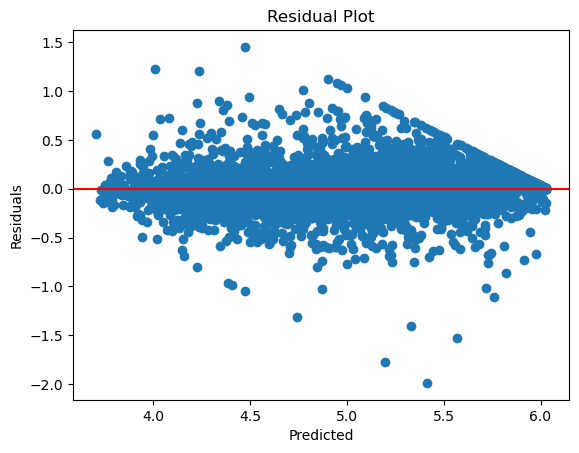

In [26]:
import matplotlib.pyplot as plt
residuals = y_test - pred
plt.scatter(pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [27]:
import pandas as pd 
new_house =pd.DataFrame(
{
    'MedInc': [1],        # income
    'HouseAge': [10],
    'AveRooms': [5],
    'AveBedrms': [1],
    'Population': [1000],
    'AveOccup': [3],
    'Latitude': [34.0],
    'Longitude': [-118.2]
})
price=best_model.predict(new_house)
print("Predicted Price :",price[0])

Predicted Price : 4.805068


In [28]:
import pickle
with open("model.pkl",'wb') as f :
    pickle.dump(best_model,f)